In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# load the csv files
df_ethiopia = pd.read_csv('../data/ethiopia_clean.csv') 
df_kenya = pd.read_csv('../data/kenya_clean.csv') 
df_nigeria = pd.read_csv('../data/nigeria_clean.csv')
df_sudan = pd.read_csv('../data/sudan_clean.csv')
df_tanzania = pd.read_csv('../data/tanzania_clean.csv')   

# concatinate the csv's

df_all = pd.concat([df_ethiopia, df_kenya, df_nigeria, df_sudan, df_tanzania], 
                   ignore_index=True)



In [19]:
df_all['Country'].value_counts()

Country
Ethiopia    4108
Kenya       4108
Nigeria     4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

**Temperature Trend Comparison**

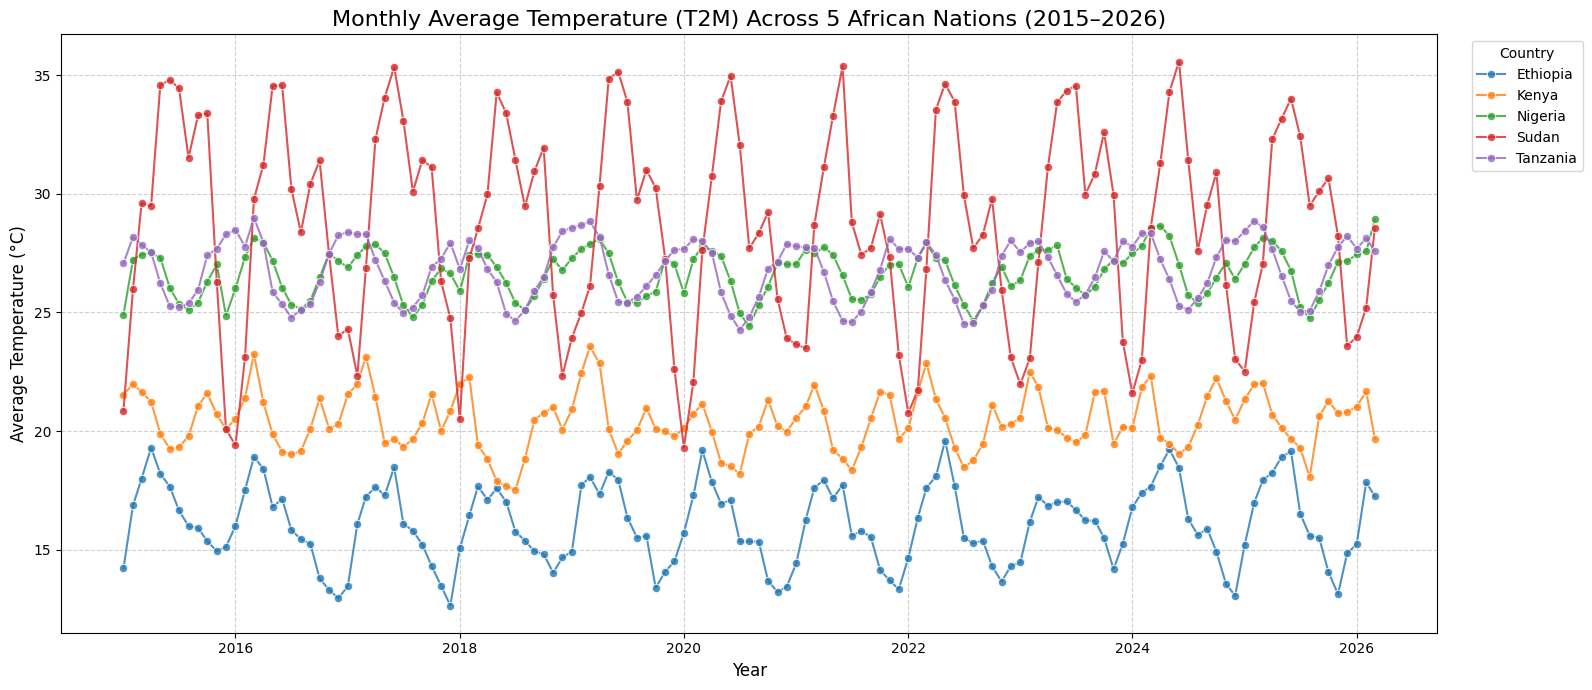

In [22]:

df_all['Date'] = pd.to_datetime(df_all['Date'])
#  Extract just the Year and Month to calculate monthly averages
df_all['YearMonth'] = df_all['Date'].dt.to_period('M')

#  Calculate the monthly average T2M for each country
monthly_t2m = df_all.groupby(['YearMonth', 'Country'])['T2M'].mean().reset_index()
# Convert 'YearMonth' back to a timestamp 
monthly_t2m['YearMonth'] = monthly_t2m['YearMonth'].dt.to_timestamp()


# VISUALIZATION: Multi-Country Line Chart=
plt.figure(figsize=(16, 7))
sns.lineplot(data=monthly_t2m, x='YearMonth', y='T2M', hue='Country', marker='o', alpha=0.8)

plt.title('Monthly Average Temperature (T2M) Across 5 African Nations (2015–2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Temperature (°C)', fontsize=12)

# Move the legend outside the plot so it doesn't cover the lines
plt.legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [23]:

# SUMMARY TABLE: Mean, Median, and Std Dev

print("\n--- Summary Statistics for Temperature (T2M) ---")
summary_table = df_all.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()

# Rename columns to look professional
summary_table.columns = ['Country', 'Mean (°C)', 'Median (°C)', 'Std Dev']

# Display the table cleanly
display(summary_table.round(2))


--- Summary Statistics for Temperature (T2M) ---


,Country,Mean (°C),Median (°C),Std Dev
0,Ethiopia,16.07,16.04,1.90
1,Kenya,20.43,20.36,1.44
2,Nigeria,26.66,26.82,1.12
3,Sudan,28.76,29.16,4.68
4,Tanzania,26.80,26.99,1.33


The temperature data shows three main climate types:

Very Hot Climate (Sudan): Sudan is the hottest country, with an average temperature of about 28.8°C. It also has large changes throughout the year, from around 20°C in winter to above 35°C in summer.
Warm and Stable Climate (Nigeria & Tanzania): These countries stay warm all year, around 26–27°C, with very little change. Their temperatures are steady and predictable.
Cooler Highlands (Ethiopia & Kenya): Because of higher land elevation, these countries are cooler. Ethiopia is the coolest, with an average of about 16°C, and shows regular seasonal patterns.

**Precipitation Variability Comparison**

C:\Users\Hermela\AppData\Local\Temp\ipykernel_12580\466757531.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='Country', y='PRECTOTCORR', palette='viridis')


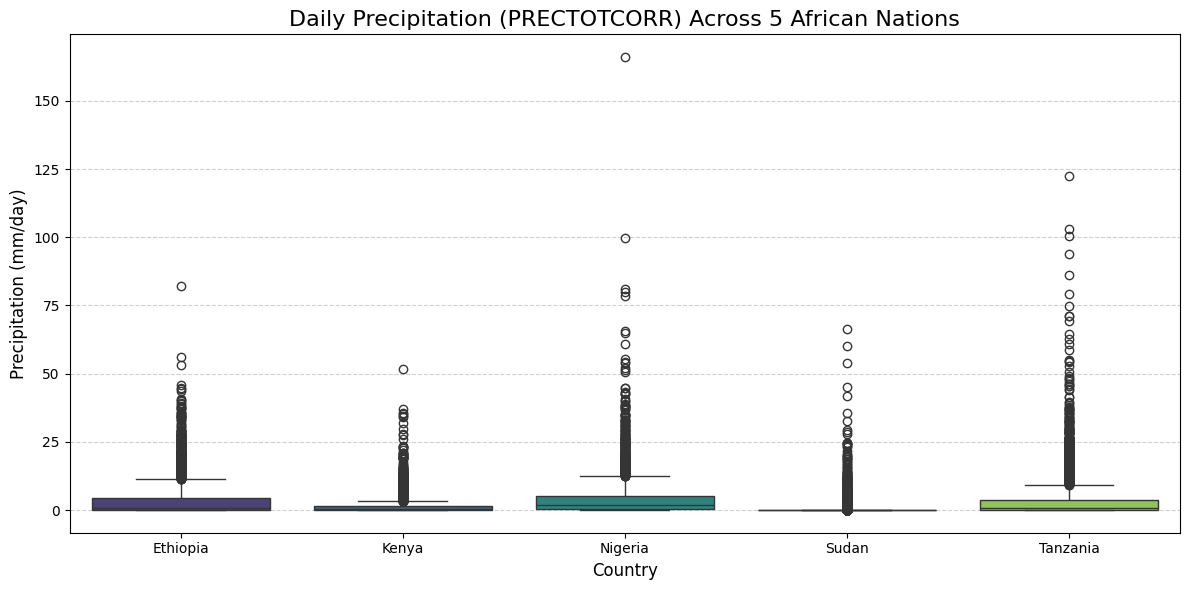

In [24]:

# VISUALIZATION: Side-by-Side Boxplots

plt.figure(figsize=(12, 6))
# Using a boxplot to show the spread of precipitation for each country
sns.boxplot(data=df_all, x='Country', y='PRECTOTCORR', palette='viridis')

plt.title('Daily Precipitation (PRECTOTCORR) Across 5 African Nations', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()




In [25]:
# SUMMARY TABLE: Mean, Median, and Std Dev

print("\n--- Summary Statistics for Precipitation (PRECTOTCORR) ---")
precip_summary = df_all.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()

# Rename columns to look professional
precip_summary.columns = ['Country', 'Mean (mm)', 'Median (mm)', 'Std Dev']

# Display the table cleanly
display(precip_summary.round(2))


--- Summary Statistics for Precipitation (PRECTOTCORR) ---


,Country,Mean (mm),Median (mm),Std Dev
0,Ethiopia,3.63,0.82,6.29
1,Kenya,1.47,0.38,3.18
2,Nigeria,4.21,1.84,7.27
3,Sudan,0.64,0.00,3.06
4,Tanzania,3.74,0.64,8.00


The rainfall data shows strong differences between dry and wet regions:

Very Dry (Sudan): Sudan gets almost no rain most of the year. The median rainfall is 0 mm, meaning many days have no rain at all.

Heavy Storms (Nigeria & Tanzania): These countries can have very strong rainstorms. Some days reach up to 166 mm in Nigeria and 120 mm in Tanzania, which can cause flooding.

**Extreme Event Frequency**

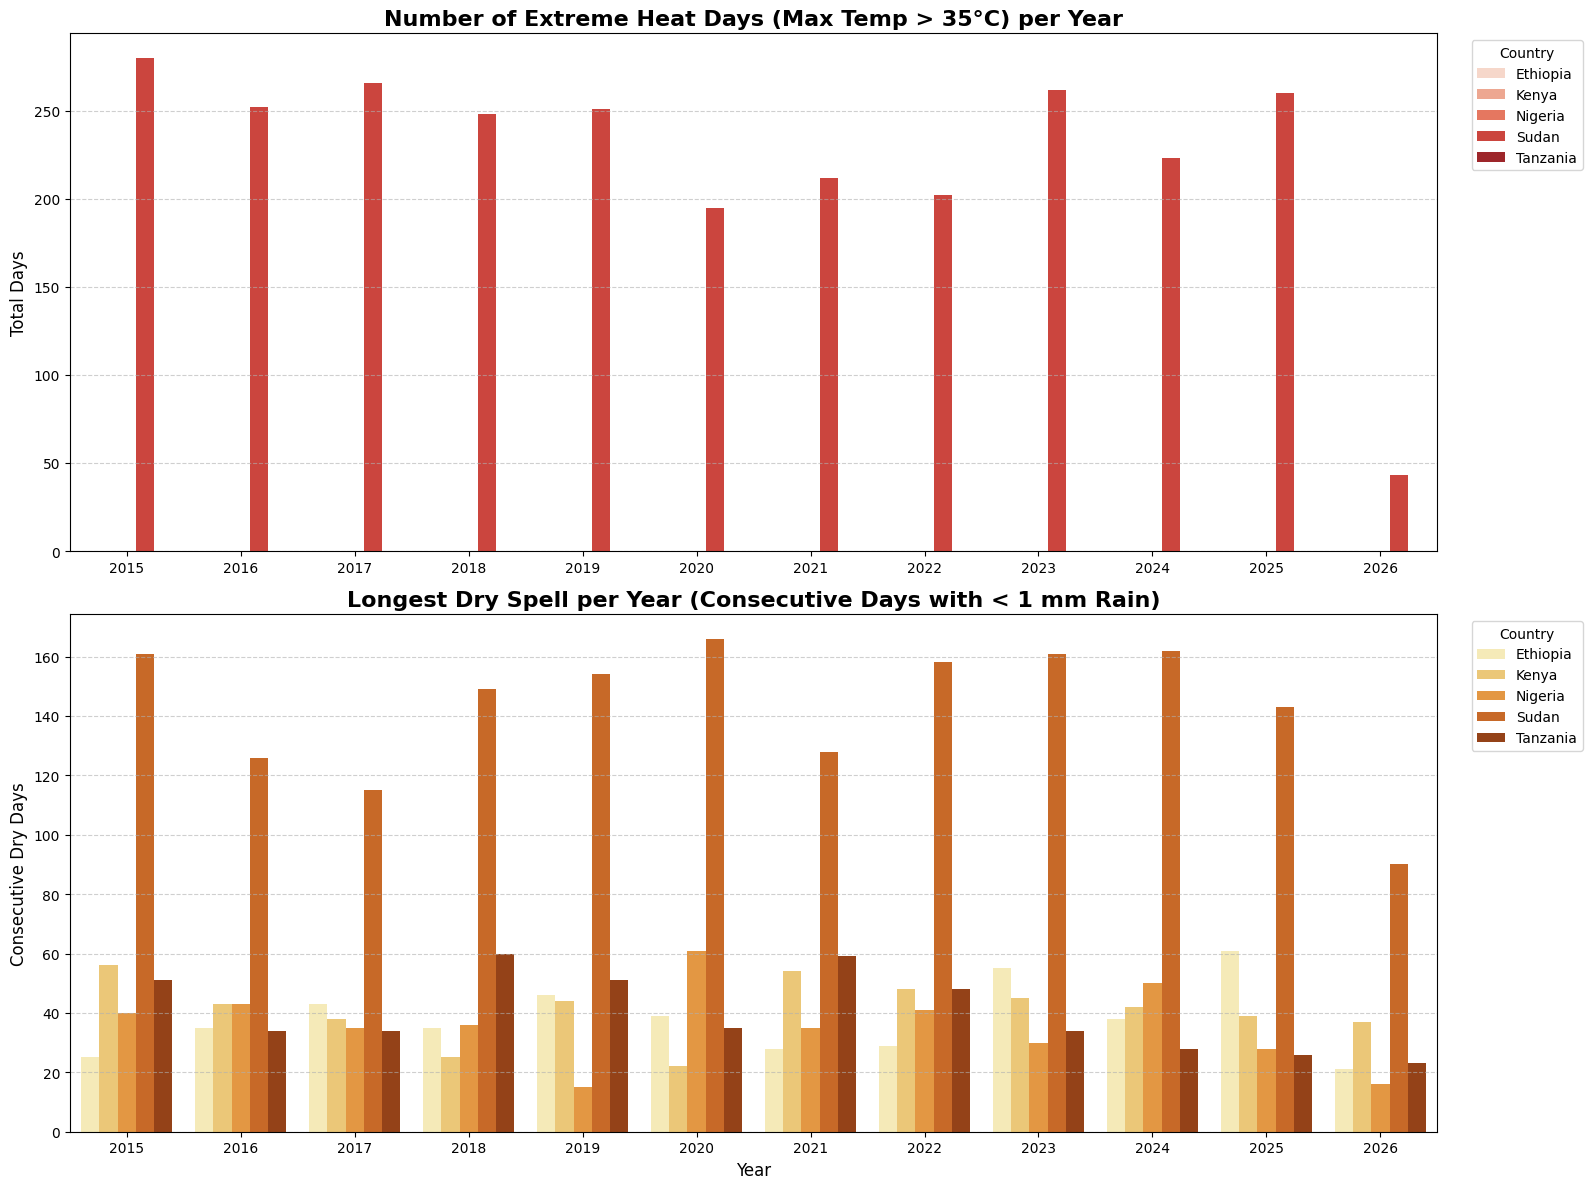

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Extreme Heat Days (T2M_MAX > 35°C)
# Create a True/False column for extreme heat
df_all['Is_Extreme_Heat'] = df_all['T2M_MAX'] > 35.0

# Group by Year and Country, then sum the True values (each True = 1 day)
heat_counts = df_all.groupby(['YEAR', 'Country'])['Is_Extreme_Heat'].sum().reset_index()
heat_counts.rename(columns={'Is_Extreme_Heat': 'Extreme_Heat_Days'}, inplace=True)

# 2. Calculate Maximum Consecutive Dry Days (< 1 mm rain)
# ==========================================================
# Create a True/False column for dry days
df_all['Is_Dry'] = df_all['PRECTOTCORR'] < 1.0

# To count *consecutive* days, we isolate the "streaks".
# Every time a wet day happens, we increase a counter. This creates unique blocks for streaks of dry days.
df_all['Wet_Day_Block'] = (~df_all['Is_Dry']).groupby([df_all['Country'], df_all['YEAR']]).cumsum()

# Count the length of each dry block
dry_streaks = df_all[df_all['Is_Dry']].groupby(['Country', 'YEAR', 'Wet_Day_Block']).size()

# Find the longest dry block (max consecutive days) for each year and country
max_cdd = dry_streaks.groupby(['Country', 'YEAR']).max().reset_index(name='Max_Consecutive_Dry_Days')

# Ensure no years are missing (if a country had 0 dry days, fill it with 0)
max_cdd = pd.merge(heat_counts[['YEAR', 'Country']], max_cdd, on=['YEAR', 'Country'], how='left').fillna(0)

# 
# 3. Visualizations: Side-by-Side Bar Charts
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Chart 1: Extreme Heat
sns.barplot(data=heat_counts, x='YEAR', y='Extreme_Heat_Days', hue='Country', ax=axes[0], palette='Reds')
axes[0].set_title('Number of Extreme Heat Days (Max Temp > 35°C) per Year', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Total Days', fontsize=12)
axes[0].set_xlabel('')
axes[0].legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Chart 2: Consecutive Dry Days
sns.barplot(data=max_cdd, x='YEAR', y='Max_Consecutive_Dry_Days', hue='Country', ax=axes[1], palette='YlOrBr')
axes[1].set_title('Longest Dry Spell per Year (Consecutive Days with < 1 mm Rain)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Consecutive Dry Days', fontsize=12)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].legend(title='Country', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Tracking average conditions is not enough to understand climate risk—extreme events give a clearer picture. The data shows strong regional differences in heat and drought exposure:

Extreme Heat (T2M_MAX > 35°C): Sudan stands out as the most affected country, experiencing around 200–250+ days per year above 35°C. The other countries rarely reach this level due to cooling effects from rainfall or higher elevation.

Consecutive Dry Days (CDD): Sudan also faces very long dry periods, lasting 140–160 days. While Nigeria and Tanzania receive high annual rainfall, they still experience dry seasons, with 40–60 consecutive days without significant rain.

In [28]:

# 1. Group the temperature (T2M) data by country
# This creates a list of temperature values for each country
groups = [group['T2M'].values for name, group in df_all.groupby('Country')]

# 2. Run One-Way ANOVA
anova_stat, anova_p = stats.f_oneway(*groups)

# 3. Run Kruskal-Wallis (Non-parametric, safer for weather data)
kw_stat, kw_p = stats.kruskal(*groups)

# 4. Display the Results cleanly
print("--- Statistical Testing for Temperature Differences ---")
print(f"One-Way ANOVA:      Statistic = {anova_stat:.2f}, p-value = {anova_p}")
print(f"Kruskal-Wallis:     Statistic = {kw_stat:.2f}, p-value = {kw_p}")

--- Statistical Testing for Temperature Differences ---
One-Way ANOVA:      Statistic = 18938.75, p-value = 0.0
Kruskal-Wallis:     Statistic = 15392.99, p-value = 0.0




Statistical Testing for Temperature Differences: Interpretation

Both the **One-Way ANOVA** and **Kruskal-Wallis** tests show extremely large test statistics and a **p-value of 0.0** (effectively less than 0.001).

This means there is **strong statistical evidence** that average temperatures are **not the same across the five countries**.

* The **ANOVA result** confirms that at least one country’s mean temperature is significantly different from the others.
* The **Kruskal-Wallis test**, which does not assume normal data, supports the same conclusion, making the result more reliable.

The differences in temperature between these countries are **statistically significant and not due to random variation**, reinforcing the idea that each country has a distinct climate profile.


**Vulnerability Ranking & Key Observations**

1. Sudan

2. Nigeria

3. Tanzania

4. Kenya

5. Ethiopia

**Key Findings & Strategic Recommendations for COP32**

1. Fastest Warming Country:
Sudan is warming the fastest. Its temperatures change a lot and reach very high levels, showing that heat is becoming more extreme and dangerous.

2. Most Unstable Rainfall:
Nigeria has the most unstable rainfall. It can go from little rain to very heavy storms in one day, which increases the risk of flooding.

3. Climate Stress (Heat & Drought):
Sudan faces the highest climate stress. It has many very hot days and very long dry periods, which makes farming and daily life much harder.

4. Ethiopia Compared to Others:
Ethiopia is cooler and more stable than the other countries. Its higher elevation keeps temperatures lower, and its weather is more predictable.

5. Priority for Climate Funding:
Ethiopia should support Sudan for climate funding. Sudan clearly faces the most extreme heat and drought, so it needs the most urgent help.